# Dataset Comparison: MODIS Snow Phenology v1 (Icechunk/Zarr v3) vs. Legacy (Zarr v2)

Compares the new `modis_snow_phenology_v1` dataset against the legacy `global_modis_snow_cover_4.zarr` tile by tile.

Checks:
- Global structure (shape, coordinates, dtypes, attributes)
- Per-tile value agreement (SAD_DOWY, SDD_DOWY, max_consec_snow_days)
- Fill value handling and valid pixel counts
- Coordinate precision differences

In [1]:
import sys
from pathlib import Path

import adlfs
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import geodatasets

sys.path.insert(0, str(Path('..').resolve()))
from modis_snow_phenology.config import Config

config = Config('config/config_v1.txt')
FILL = np.iinfo(np.int16).min  # -32768
VARS = ['SAD_DOWY', 'SDD_DOWY', 'max_consec_snow_days']

In [2]:
modis_grid_crs = gpd.read_file(
    'zip+http://book.ecosens.org/wp-content/uploads/2016/06/modis_grid.zip'
    '!modis_sinusoidal_grid_world.shp'
).crs
modis_grid_gdf = gpd.read_file(config.tile_status_path).set_crs(modis_grid_crs, allow_override=True)
modis_grid_gdf

,tile,h,v,land,processing_status,notes,geometry
0,h00v17,0,17,False,skip,Skip because no land intersection.,"POLYGON ((-19649629.667 -10010000, -20020000 -..."
1,h01v17,1,17,False,skip,Skip because no land intersection.,"POLYGON ((-18538518.667 -10010000, -18908889 -..."
2,h02v17,2,17,False,skip,Skip because no land intersection.,"POLYGON ((-17427407.667 -10010000, -17797778 -..."
3,h03v17,3,17,False,skip,Skip because no land intersection.,"POLYGON ((-16316296.667 -10010000, -16686667 -..."
4,h04v17,4,17,False,skip,Skip because no land intersection.,"POLYGON ((-15205185.667 -10010000, -15575556 -..."
...,...,...,...,...,...,...,...
643,h31v00,31,0,False,skip,Skip because no land intersection.,"POLYGON ((14794811.333 8878887, 14424441 88788..."
644,h32v00,32,0,False,skip,Skip because no land intersection.,"POLYGON ((15905922.333 8878887, 15535552 88788..."
645,h33v00,33,0,False,skip,Skip because no land intersection.,"POLYGON ((17017033.333 8878887, 16646663 88788..."
646,h34v00,34,0,False,skip,Skip because no land intersection.,"POLYGON ((18128144.333 8878887, 17757774 88788..."


In [3]:
land_proj_gdf = gpd.read_file(geodatasets.get_url('naturalearth land')).to_crs(modis_grid_gdf.crs)
land_proj_gdf

,featurecla,scalerank,min_zoom,geometry
0,Land,1,1.0,"POLYGON ((-1145691.858 -8900071.834, -1092996...."
1,Land,1,1.0,"POLYGON ((-3227038.432 -8839679.654, -3223765...."
2,Land,1,0.0,"POLYGON ((-1039886.559 -8678447.961, -975497.8..."
3,Land,1,1.0,"POLYGON ((-3827769.578 -8172946.459, -3751959...."
4,Land,1,1.0,"POLYGON ((-3969665.743 -8170762.917, -3830831...."
...,...,...,...,...
122,Land,1,1.0,"POLYGON ((933847.592 8956459.006, 921897.062 8..."
123,Land,0,0.0,"POLYGON ((2143086.928 8771170.223, 2119516.987..."
124,Land,0,0.0,"POLYGON ((-1736770.792 8857797.84, -1765616.28..."
125,Land,0,0.0,"POLYGON ((-914231.313 9241011.741, -888492.28 ..."


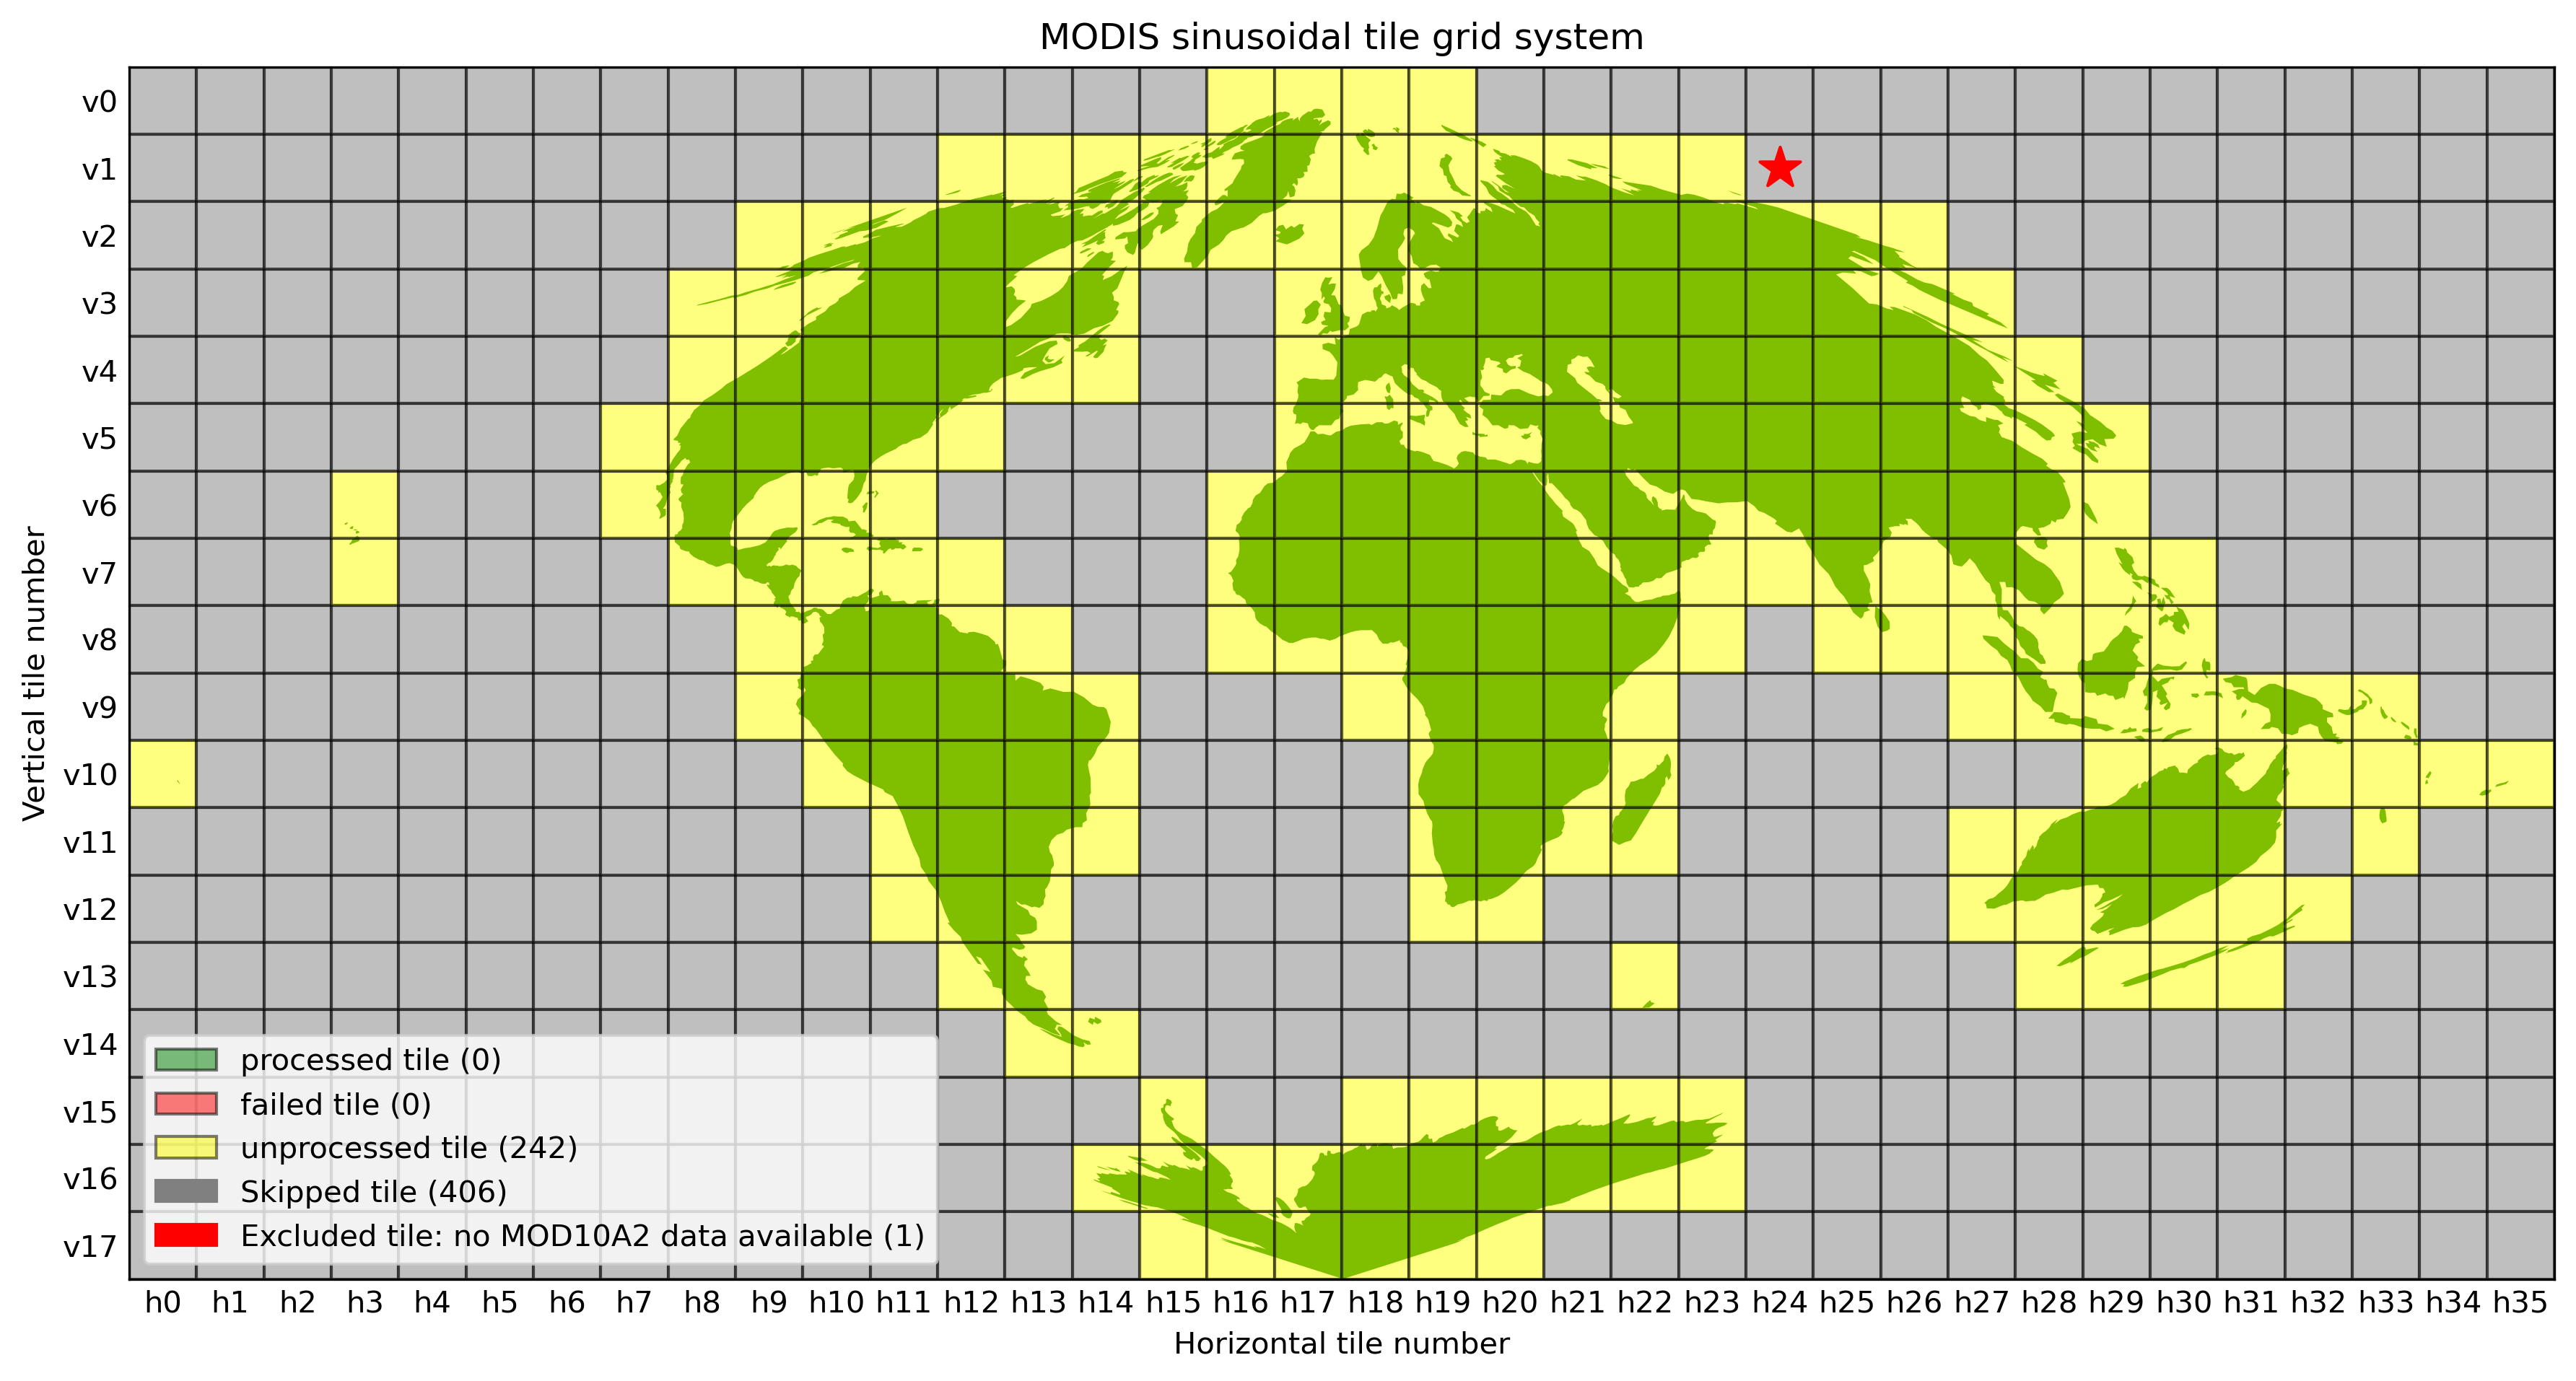

In [4]:
f, ax = plt.subplots(figsize=(12,7),dpi=300)

land_proj_gdf.plot(ax=ax, color='green',zorder=0)

modis_grid_gdf.plot(ax=ax, facecolor=modis_grid_gdf['processing_status'].map({'failed': 'red', 'processed': 'green', 'skip': 'gray', 'unprocessed': 'yellow'}), edgecolor='black', alpha=0.5, zorder=1)

# plot asterisk at centroid of each tile manually excluded
excluded_tiles = modis_grid_gdf[modis_grid_gdf['notes'] == 'Skip because no MOD10A2 data available.']
excluded_tiles_centroids = excluded_tiles.geometry.centroid
ax.scatter(excluded_tiles_centroids.x, excluded_tiles_centroids.y, marker='*', color='red', s=200, label='Manually excluded tile (no data available)', zorder=2)


ax.set_title(f'MODIS sinusoidal tile grid system')
ax.set_xlabel('Horizontal tile number')
ax.set_ylabel('Vertical tile number')

# create tick labels for h and v values, using the mean centroid of the tiles in each row/column to position the ticks
h_values = sorted(modis_grid_gdf['h'].unique())
v_values = sorted(modis_grid_gdf['v'].unique(), reverse=True)

h_coords = [modis_grid_gdf[modis_grid_gdf['h'] == h].geometry.centroid.x.mean() for h in h_values]
v_coords = [modis_grid_gdf[modis_grid_gdf['v'] == v].geometry.centroid.y.mean() for v in v_values]

ax.set_xticks(h_coords)
ax.set_xticklabels([f'h{h}' for h in h_values])
ax.set_yticks(v_coords)
ax.set_yticklabels([f'v{v}' for v in v_values])

ax.tick_params(axis='both', which='both', length=0)

ax.set_xlim(modis_grid_gdf.total_bounds[0], modis_grid_gdf.total_bounds[2])
ax.set_ylim(modis_grid_gdf.total_bounds[1], modis_grid_gdf.total_bounds[3])

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.5, edgecolor='black', label=f'processed tile ({modis_grid_gdf[modis_grid_gdf["processing_status"] == "processed"].shape[0]})'),
                   Patch(facecolor='red', alpha=0.5, edgecolor='black', label=f'failed tile ({modis_grid_gdf[modis_grid_gdf["processing_status"] == "failed"].shape[0]})'),
                   Patch(facecolor='yellow', alpha=0.5, edgecolor='black', label=f'unprocessed tile ({modis_grid_gdf[modis_grid_gdf["processing_status"] == "unprocessed"].shape[0]})'),
                   Patch(facecolor='gray', edgecolor='gray', label=f'Skipped tile ({modis_grid_gdf[modis_grid_gdf["processing_status"] == "skip"].shape[0]})'),
                   Patch(facecolor='red', edgecolor='red', label=f'Excluded tile: no MOD10A2 data available ({excluded_tiles.shape[0]})')]
ax.legend(handles=legend_elements, loc='lower left')

ax.set_aspect('equal', adjustable='box')

f.tight_layout()

## Open both stores

In [5]:
# New store — Icechunk / Zarr v3
storage = icechunk.azure_storage(
    account=config.azure_storage_account,
    container=config.azure_container,
    prefix=config.icechunk_prefix,
    sas_token=config.azure_storage_sas_token,
)
repo = icechunk.Repository.open(storage)
session = repo.readonly_session('main')
new_ds = xr.open_zarr(session.store, zarr_format=3, consolidated=False, decode_coords='all')
print('New store:')
print(new_ds)

New store:
<xarray.Dataset> Size: 448GB
Dimensions:               (water_year: 10, y: 43200, x: 86400)
Coordinates:
  * water_year            (water_year) int64 80B 2015 2016 2017 ... 2023 2024
  * y                     (y) float64 346kB 1.001e+07 1.001e+07 ... -1.001e+07
  * x                     (x) float64 691kB -2.001e+07 -2.001e+07 ... 2.001e+07
    spatial_ref           int64 8B ...
Data variables:
    SAD_DOWY              (water_year, y, x) float32 149GB dask.array<chunksize=(1, 600, 600), meta=np.ndarray>
    max_consec_snow_days  (water_year, y, x) float32 149GB dask.array<chunksize=(1, 600, 600), meta=np.ndarray>
    SDD_DOWY              (water_year, y, x) float32 149GB dask.array<chunksize=(1, 600, 600), meta=np.ndarray>
Attributes:
    title:        Global MODIS Snow Phenology
    description:  Snow appearance date (SAD), snow disappearance date (SDD), ...
    source:       MODIS MOD10A2.061 via Microsoft Planetary Computer
    Conventions:  CF-1.8


In [6]:
# Legacy store — Zarr v2 on Azure Blob
old_sas = config.azure_storage_sas_token
old_fs = adlfs.AzureBlobFileSystem(account_name=config.azure_storage_account, credential=old_sas)
old_store = old_fs.get_mapper('snowmelt/snow_cover/global_modis_snow_cover.zarr')
old_ds = xr.open_zarr(old_store, consolidated=True, decode_coords='all')
print('Legacy store:')
print(old_ds)

Legacy store:
<xarray.Dataset> Size: 448GB
Dimensions:               (water_year: 10, y: 43200, x: 86400)
Coordinates:
  * water_year            (water_year) int64 80B 2015 2016 2017 ... 2023 2024
  * y                     (y) float64 346kB 1.001e+07 1.001e+07 ... -1.001e+07
  * x                     (x) float64 691kB -2.001e+07 -2.001e+07 ... 2.001e+07
    spatial_ref           int64 8B ...
Data variables:
    SAD_DOWY              (water_year, y, x) float32 149GB dask.array<chunksize=(1, 2400, 2400), meta=np.ndarray>
    SDD_DOWY              (water_year, y, x) float32 149GB dask.array<chunksize=(1, 2400, 2400), meta=np.ndarray>
    max_consec_snow_days  (water_year, y, x) float32 149GB dask.array<chunksize=(1, 2400, 2400), meta=np.ndarray>
Attributes:
    processed_tiles:  ['h18_v17', 'h15_v16', 'h19_v17', 'h18_v16', 'h17_v17',...


In [7]:
for var in VARS:
    print(f'Variable: {var}')
    print(f'  New encoding: {new_ds[var].encoding}')
    print(f'  Old encoding: {old_ds[var].encoding}')

Variable: SAD_DOWY
  New encoding: {'chunks': (1, 600, 600), 'preferred_chunks': {'water_year': 1, 'y': 600, 'x': 600}, 'compressors': (BloscCodec(_tunable_attrs=set(), typesize=2, cname=<BloscCname.zstd: 'zstd'>, clevel=5, shuffle=<BloscShuffle.shuffle: 'shuffle'>, blocksize=0),), 'filters': (), 'shards': (1, 2400, 2400), 'serializer': BytesCodec(endian=<Endian.little: 'little'>), '_FillValue': -32768, 'dtype': dtype('<i2'), 'grid_mapping': 'spatial_ref'}
  Old encoding: {'chunks': (1, 2400, 2400), 'preferred_chunks': {'water_year': 1, 'y': 2400, 'x': 2400}, 'compressors': (Blosc(cname='zstd', clevel=5, shuffle=SHUFFLE, blocksize=0),), 'filters': (), 'shards': None, '_FillValue': np.int16(-32768), 'dtype': dtype('<i2'), 'grid_mapping': 'spatial_ref'}
Variable: SDD_DOWY
  New encoding: {'chunks': (1, 600, 600), 'preferred_chunks': {'water_year': 1, 'y': 600, 'x': 600}, 'compressors': (BloscCodec(_tunable_attrs=set(), typesize=2, cname=<BloscCname.zstd: 'zstd'>, clevel=5, shuffle=<Blosc

## Global structure comparison

In [8]:
print('=== Shape ===')
for v in VARS:
    s_new = new_ds[v].shape
    s_old = old_ds[v].shape
    match = '✅' if s_new == s_old else '❌'
    print(f'  {v}: new={s_new}  old={s_old}  {match}')

print()
print('=== Dtype ===')
for v in VARS:
    # encoded
    d_new = new_ds[v].dtype
    d_old = old_ds[v].dtype
    match = '✅' if d_new == d_old else '⚠️ '
    print(f'  {v}: new={d_new}  old={d_old}  {match}')

print()
print('=== Water years ===')
wy_new = new_ds.water_year.values
wy_old = old_ds.water_year.values
print(f'  new: {wy_new}')
print(f'  old: {wy_old}')
print(f'  match: {"✅" if np.array_equal(wy_new, wy_old) else "❌"}')

print()
print('=== Coordinate ranges ===')
for coord in ['y', 'x']:
    c_new = new_ds[coord].values
    c_old = old_ds[coord].values
    close = np.allclose(c_new, c_old, atol=1.0)
    max_diff = np.max(np.abs(c_new - c_old)) if len(c_new) == len(c_old) else 'length mismatch'
    print(f'  {coord}: len new={len(c_new)}, old={len(c_old)}, max_diff={max_diff:.4f}m  {"✅" if close else "❌"}')

print()
print('=== CRS ===')
try:
    import rioxarray  # noqa: F401
    crs_new = new_ds.rio.crs
    crs_old = old_ds.rio.crs
    print(f'  new: {crs_new}')
    print(f'  old: {crs_old}')
    print(f'  match: {"✅" if crs_new == crs_old else "⚠️ (check proj strings)"}')
except Exception as e:
    print(f'  CRS comparison error: {e}')

print()
print('=== Global attributes ===')
print('  new attrs:', dict(new_ds.attrs))
print('  old attrs:', dict(old_ds.attrs))

=== Shape ===
  SAD_DOWY: new=(10, 43200, 86400)  old=(10, 43200, 86400)  ✅
  SDD_DOWY: new=(10, 43200, 86400)  old=(10, 43200, 86400)  ✅
  max_consec_snow_days: new=(10, 43200, 86400)  old=(10, 43200, 86400)  ✅

=== Dtype ===
  SAD_DOWY: new=float32  old=float32  ✅
  SDD_DOWY: new=float32  old=float32  ✅
  max_consec_snow_days: new=float32  old=float32  ✅

=== Water years ===
  new: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
  old: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
  match: ✅

=== Coordinate ranges ===
  y: len new=43200, old=43200, max_diff=0.0000m  ✅
  x: len new=86400, old=86400, max_diff=0.0000m  ✅

=== CRS ===
  new: PROJCS["unnamed",GEOGCS["Unknown datum based upon the custom spheroid",DATUM["Not specified (based on custom spheroid)",SPHEROID["Custom spheroid",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETE

## Per-tile value comparison

For each tile, extract data from both stores and compare.

In [9]:
v = 3
h = 10
y_sl = slice(v * 2400, (v + 1) * 2400)
x_sl = slice(h * 2400, (h + 1) * 2400)

new_tile_ds = new_ds.isel(y=y_sl, x=x_sl).compute()
old_tile_ds = old_ds.isel(y=y_sl, x=x_sl).compute()
diff_tile_ds = new_tile_ds - old_tile_ds

# make a NaN disagreement ds (nan_disagreement_ds) where values are 1 when new_tile_ds has NaN and old_tile_ds does not, -1 when old_tile_ds has NaN and new_tile_ds does not, and 0 when they agree (both NaN or both valid)
nan_disagreement_ds = xr.where(np.isnan(new_tile_ds) & ~np.isnan(old_tile_ds), 1,
                        xr.where(~np.isnan(new_tile_ds) & np.isnan(old_tile_ds), -1, 0))

In [10]:
diff_tile_ds# = diff_tile_ds.compute()

<xarray.Dataset> Size: 691MB
Dimensions:               (water_year: 10, x: 2400, y: 2400)
Coordinates:
  * water_year            (water_year) int64 80B 2015 2016 2017 ... 2023 2024
  * x                     (x) float64 19kB -8.895e+06 -8.895e+06 ... -7.784e+06
  * y                     (y) float64 19kB 6.671e+06 6.671e+06 ... 5.56e+06
    spatial_ref           int64 8B 0
Data variables:
    SAD_DOWY              (water_year, y, x) float32 230MB 0.0 0.0 ... 0.0 0.0
    max_consec_snow_days  (water_year, y, x) float32 230MB 0.0 0.0 ... 0.0 0.0
    SDD_DOWY              (water_year, y, x) float32 230MB 0.0 0.0 ... 0.0 0.0
Attributes:
    title:            Global MODIS Snow Phenology
    description:      Snow appearance date (SAD), snow disappearance date (SD...
    source:           MODIS MOD10A2.061 via Microsoft Planetary Computer
    Conventions:      CF-1.8
    processed_tiles:  ['h18_v17', 'h15_v16', 'h19_v17', 'h18_v16', 'h17_v17',...

In [11]:
nan_disagreement_ds

<xarray.Dataset> Size: 1GB
Dimensions:               (water_year: 10, y: 2400, x: 2400)
Coordinates:
  * water_year            (water_year) int64 80B 2015 2016 2017 ... 2023 2024
  * y                     (y) float64 19kB 6.671e+06 6.671e+06 ... 5.56e+06
  * x                     (x) float64 19kB -8.895e+06 -8.895e+06 ... -7.784e+06
    spatial_ref           int64 8B 0
Data variables:
    SAD_DOWY              (water_year, y, x) int64 461MB 0 0 0 0 0 ... 0 0 0 0 0
    max_consec_snow_days  (water_year, y, x) int64 461MB 0 0 0 0 0 ... 0 0 0 0 0
    SDD_DOWY              (water_year, y, x) int64 461MB 0 0 0 0 0 ... 0 0 0 0 0

In [ ]:
diff_tile_ds['SAD_DOWY'].plot.imshow(col="water_year", col_wrap= 10, vmin=-10, vmax=10,cmap='RdBu',)
diff_tile_ds['SDD_DOWY'].plot.imshow(col="water_year", col_wrap=10, vmin=-10, vmax=10,cmap='RdBu',)
diff_tile_ds['max_consec_snow_days'].plot.imshow(col="water_year", col_wrap=10, vmin=-10, vmax=10, cmap='RdBu',)

## Per-tile comparison vs. legacy store

For each tile present in both the new (Icechunk/Zarr v3) and legacy (Zarr v2) stores, compute agreement stats aggregated across all water years. Results are saved tile-by-tile to `notebooks/tile_comparison_stats.geojson`; re-run the loop cell to resume from where it left off.

In [ ]:
STAT_COLS = []
for _var in VARS:
    STAT_COLS += [
        f'{_var}_valid_new',       f'{_var}_valid_old',
        f'{_var}_nan_only_in_new', f'{_var}_nan_only_in_old',
        f'{_var}_mean_diff',       f'{_var}_max_diff',
        f'{_var}_pct_match_1d',    f'{_var}_pct_match_8d',    f'{_var}_pct_match_16d',
    ]


def compare_tile(h, v, new_ds=new_ds, old_ds=old_ds):
    """Compare new vs. old store for one MODIS tile.

    Stats are aggregated across all water years. Returns a flat dict keyed by
    '{var}_{metric}'. NaN in the stats means no co-valid pixels existed.
    """
    y_sl = slice(v * 2400, (v + 1) * 2400)
    x_sl = slice(h * 2400, (h + 1) * 2400)

    new_tile = new_ds.isel(y=y_sl, x=x_sl).compute()
    old_tile = old_ds.isel(y=y_sl, x=x_sl).compute()

    stats = {}
    for var in VARS:
        n = new_tile[var].values.ravel()
        o = old_tile[var].values.ravel()

        valid_n   = ~np.isnan(n)
        valid_o   = ~np.isnan(o)
        both_valid = valid_n & valid_o
        n_both     = int(both_valid.sum())
        diff       = np.abs(n[both_valid] - o[both_valid])

        stats[f'{var}_valid_new']       = int(valid_n.sum())
        stats[f'{var}_valid_old']       = int(valid_o.sum())
        stats[f'{var}_nan_only_in_new'] = int((~valid_n & valid_o).sum())  # data loss in new
        stats[f'{var}_nan_only_in_old'] = int((valid_n & ~valid_o).sum())  # coverage gain in new

        if n_both > 0:
            stats[f'{var}_mean_diff']    = float(diff.mean())
            stats[f'{var}_max_diff']     = float(diff.max())
            stats[f'{var}_pct_match_1d'] = float((diff <= 1).sum()  / n_both * 100)
            stats[f'{var}_pct_match_8d'] = float((diff <= 8).sum()  / n_both * 100)
            stats[f'{var}_pct_match_16d']= float((diff <= 16).sum() / n_both * 100)
        else:
            for key in ['mean_diff', 'max_diff', 'pct_match_1d', 'pct_match_8d', 'pct_match_16d']:
                stats[f'{var}_{key}'] = float('nan')

    return stats

In [ ]:
COMPARISON_PATH = Path('notebooks/tile_comparison_stats.geojson')

if COMPARISON_PATH.exists():
    comp_gdf = gpd.read_file(COMPARISON_PATH).set_crs(modis_grid_gdf.crs, allow_override=True)
    n_done = (comp_gdf['comparison_status'] == 'done').sum()
    print(f"Loaded: {n_done} / {len(comp_gdf)} tiles done")
else:
    # Parse old store tile IDs from attrs (format: 'h18_v17' -> 'h18v17')
    old_tiles = set()
    for t in old_ds.attrs.get('processed_tiles', []):
        h_part, v_part = t.split('_')
        old_tiles.add(f"h{int(h_part[1:]):02d}v{int(v_part[1:]):02d}")

    # Tiles present in both new (processed) and old stores
    mask = (modis_grid_gdf['processing_status'] == 'processed') & modis_grid_gdf['tile'].isin(old_tiles)
    comp_gdf = modis_grid_gdf[mask].copy()
    for col in STAT_COLS:
        comp_gdf[col] = float('nan')
    comp_gdf['comparison_status'] = 'pending'
    print(f"Initialized: {len(comp_gdf)} tiles to compare ({len(old_tiles)} in old store)")

In [ ]:
pending = comp_gdf[comp_gdf['comparison_status'] == 'pending']
print(f"Pending: {len(pending)} tiles\n")

for idx, row in pending.iterrows():
    h, v, tile_id = int(row['h']), int(row['v']), row['tile']
    print(f"[{tile_id}] computing...", end=' ', flush=True)
    try:
        stats = compare_tile(h, v)
        for col, val in stats.items():
            comp_gdf.at[idx, col] = val
        comp_gdf.at[idx, 'comparison_status'] = 'done'
        print(
            f"✅  SAD={stats['SAD_DOWY_mean_diff']:.3f}  "
            f"SDD={stats['SDD_DOWY_mean_diff']:.3f}  "
            f"mcs={stats['max_consec_snow_days_mean_diff']:.3f}"
        )
    except Exception as e:
        print(f"❌  {e}")
        comp_gdf.at[idx, 'comparison_status'] = 'error'

    comp_gdf.to_file(COMPARISON_PATH, driver='GeoJSON')

n_done = (comp_gdf['comparison_status'] == 'done').sum()
n_err  = (comp_gdf['comparison_status'] == 'error').sum()
n_pend = (comp_gdf['comparison_status'] == 'pending').sum()
print(f"\nDone: {n_done}  Error: {n_err}  Remaining: {n_pend}")

In [ ]:
import folium
import ipywidgets as widgets
from IPython.display import display

comp_gdf_wgs84 = comp_gdf[comp_gdf['comparison_status'] == 'done'].to_crs('EPSG:4326')

METRIC_OPTIONS = [
    ('Mean |diff| (days)',               'mean_diff'),
    ('Max |diff| (days)',                'max_diff'),
    ('% pixels matching ≤1 day',        'pct_match_1d'),
    ('% pixels matching ≤8 days',       'pct_match_8d'),
    ('% pixels matching ≤16 days',      'pct_match_16d'),
    ('NaN only in new (data loss)',      'nan_only_in_new'),
    ('NaN only in old (coverage gain)',  'nan_only_in_old'),
    ('Valid pixels — new',               'valid_new'),
    ('Valid pixels — old',               'valid_old'),
]

var_widget = widgets.Dropdown(
    options=VARS, value=VARS[0], description='Variable:', style={'description_width': 'initial'}
)
metric_widget = widgets.Dropdown(
    options=METRIC_OPTIONS, description='Metric:', style={'description_width': 'initial'}
)
map_out = widgets.Output()

def make_comparison_map(gdf, var, metric_key):
    col = f'{var}_{metric_key}'
    valid_vals = gdf[col].dropna()
    if len(valid_vals) == 0:
        return folium.Map(location=[20, 0], zoom_start=2)

    vmin = float(valid_vals.quantile(0.05))
    vmax = float(valid_vals.quantile(0.95))
    if vmin == vmax:
        vmax = vmin + 1
    thresholds = list(np.linspace(vmin, vmax, 7))

    m = folium.Map(location=[20, 0], zoom_start=2, tiles='CartoDB positron')
    cp = folium.Choropleth(
        geo_data=gdf.__geo_interface__,
        data=gdf[['tile', col]],
        columns=['tile', col],
        key_on='feature.properties.tile',
        fill_color='YlOrRd',
        fill_opacity=0.75,
        line_opacity=0.3,
        nan_fill_color='lightgray',
        nan_fill_opacity=0.3,
        legend_name=f'{var}  —  {col}',
        threshold_scale=thresholds,
    ).add_to(m)

    tooltip_fields = ['tile'] + [f'{v}_{metric_key}' for v in VARS]
    tooltip_aliases = ['Tile'] + [f'{v}:' for v in VARS]
    cp.geojson.add_child(folium.features.GeoJsonTooltip(
        fields=tooltip_fields,
        aliases=tooltip_aliases,
        localize=True,
        sticky=True,
    ))
    return m

def update_map(change=None):
    with map_out:
        map_out.clear_output(wait=True)
        display(make_comparison_map(comp_gdf_wgs84, var_widget.value, metric_widget.value))

var_widget.observe(update_map, names='value')
metric_widget.observe(update_map, names='value')

display(widgets.HBox([var_widget, metric_widget]))
display(map_out)
update_map()